<a href="https://colab.research.google.com/github/angelonavarrogit/-S100-ANALITICA-DATOS-PROYECTO-FINAL-/blob/main/S100_EquipoN7_ParteII.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo predictivo: `es_fresco` — netflix_titles.csv
### Proyecto Final · Introducción a la Ciencia de Datos (S100) · Equipo 7

Este notebook construye y evalúa el modelo que sustenta el white paper: predecir si un
título entra al catálogo de Netflix **fresco** (dentro de su primer año de estreno) o
**de catálogo** (después), incorporando la retroalimentación del profesor.

**Qué cambió respecto al primer intento:** la variable objetivo ya no es `type`
(Movie/TV Show) — se descartó por fuga de datos (`duration`, `listed_in` y `rating`
la determinan casi al 100%). La nueva variable objetivo es `es_fresco`, construida a
partir de `date_added` y `release_year`.

**Cómo usarlo:** coloca `netflix_titles.csv` en la misma carpeta que este notebook y
ejecuta las celdas en orden.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("netflix_titles.csv")
n_inicial = len(df)
print(f"Filas iniciales: {n_inicial}")


Filas iniciales: 8807


## 1. Construir la variable objetivo: `es_fresco`

```
año_agregado = año de date_added
antigüedad   = año_agregado - release_year
es_fresco    = 1 si antigüedad <= 1, si no 0
```

`release_year` y `año_agregado` **no pueden ser predictoras** — son justo las columnas
con las que se construye el objetivo (sería fuga de datos en sentido inverso).


In [ ]:
df["anio_agregado"] = pd.to_datetime(df["date_added"].str.strip(), errors="coerce").dt.year

# Sin date_added no se puede calcular el objetivo -> se descartan esas filas
n_antes = len(df)
df = df.dropna(subset=["anio_agregado"]).copy()
print(f"Títulos descartados por date_added faltante: {n_antes - len(df)}")

df["antiguedad"] = df["anio_agregado"] - df["release_year"]
df["es_fresco"] = (df["antiguedad"] <= 1).astype(int)

print(f"\nFilas tras esta limpieza: {len(df)}")
print(f"Balance de clases -> fresco: {df['es_fresco'].mean():.1%}  |  de catálogo: {1-df['es_fresco'].mean():.1%}")


Títulos descartados por date_added faltante: 10

Filas tras esta limpieza: 8797
Balance de clases -> fresco: 55.0%  |  de catálogo: 45.0%


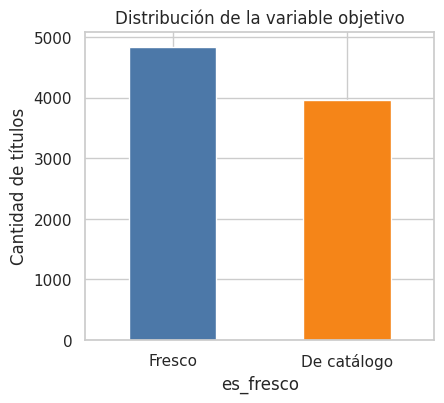

In [ ]:
df["es_fresco"].value_counts().rename({1: "Fresco", 0: "De catálogo"}).plot(
    kind="bar", color=["#4C78A8", "#F58518"], edgecolor="white", figsize=(4.5, 4)
)
plt.title("Distribución de la variable objetivo")
plt.ylabel("Cantidad de títulos")
plt.xticks(rotation=0)
plt.show()


## 2. Hipótesis: "las series entran al catálogo más frescas que las películas"

Se contrasta con un `groupby` de dos líneas, antes de entrenar cualquier modelo.


In [ ]:
tabla_hipotesis = df.groupby("type")["es_fresco"].agg(pct_fresco="mean", n="count")
tabla_hipotesis["pct_fresco"] = (tabla_hipotesis["pct_fresco"] * 100).round(1)
print(tabla_hipotesis)

diferencia = tabla_hipotesis.loc["TV Show", "pct_fresco"] - tabla_hipotesis.loc["Movie", "pct_fresco"]
print(f"\nDiferencia: {diferencia:.1f} puntos porcentuales -> la hipótesis se CONFIRMA.")


         pct_fresco     n
type                     
Movie          49.6  6131
TV Show        67.4  2666

Diferencia: 17.8 puntos porcentuales -> la hipótesis se CONFIRMA.


## 3. Limpieza y codificación de las predictoras

Predictoras legítimas (según el profesor): `type`, `listed_in` (género), `rating`,
`country`. Cada decisión de limpieza está justificada en el white paper (sección 2);
aquí se aplica en código.


In [ ]:
# 'rating': 4 faltantes + 3 valores invalidos por un error de desplazamiento de
# columnas en el CSV original (ej. "66 min" en vez de una clasificacion real).
# Ambos casos se tratan igual: se imputan con la moda.
mask_rating_invalido = df["rating"].str.contains(r"^\d+\s*min$", na=False, regex=True)
print(f"Valores de 'rating' inválidos detectados: {mask_rating_invalido.sum()}")
df.loc[mask_rating_invalido, "rating"] = np.nan
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

# 'country': pais principal (primero listado); faltante -> categoria propia 'Unknown'
df["pais_principal"] = df["country"].fillna("Unknown").str.split(", ").str[0]
top_paises = df["pais_principal"].value_counts().head(10).index.tolist()
df["pais_principal_agrupado"] = np.where(df["pais_principal"].isin(top_paises), df["pais_principal"], "Otros")
print("Categorías de país usadas:", top_paises + ["Otros"])


Valores de 'rating' inválidos detectados: 3
Categorías de país usadas: ['United States', 'India', 'Unknown', 'United Kingdom', 'Canada', 'Japan', 'France', 'South Korea', 'Spain', 'Mexico', 'Otros']


In [ ]:
# 'listed_in': columnas binarias para los 15 generos mas frecuentes (multietiqueta)
generos_split = df["listed_in"].str.split(", ")
top_generos = generos_split.explode().value_counts().head(15).index.tolist()

for g in top_generos:
    col = "genero_" + g.lower().replace(" ", "_").replace("&", "y").replace("-", "_")
    df[col] = generos_split.apply(lambda lst: int(g in lst))

genero_cols = [c for c in df.columns if c.startswith("genero_")]
print(f"{len(genero_cols)} columnas de género creadas.")


15 columnas de género creadas.


In [ ]:
# Ensamblar X (predictoras) y y (objetivo). Codificacion: One-Hot para type/rating/pais;
# las columnas de genero ya son binarias. Sin escalamiento: todo es categorico/binario.
cat_cols = ["type", "rating", "pais_principal_agrupado"]
X_cat = pd.get_dummies(df[cat_cols], drop_first=False)
X = pd.concat([X_cat, df[genero_cols]], axis=1)
y = df["es_fresco"]

print(f"Filas finales para modelar: {len(X)}")
print(f"Variables predictoras finales: {X.shape[1]}")


Filas finales para modelar: 8797
Variables predictoras finales: 42


## 4. Separar entrenamiento y prueba

80% entrenamiento / 20% prueba, **estratificado** sobre `es_fresco` (para que ambos
conjuntos conserven el mismo balance de clases), con `random_state=42` fijo para que el
resultado sea reproducible.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Entrenamiento: {len(X_train)} filas ({y_train.mean():.1%} frescos)")
print(f"Prueba:        {len(X_test)} filas ({y_test.mean():.1%} frescos)")


Entrenamiento: 7037 filas (55.0% frescos)
Prueba:        1760 filas (55.0% frescos)


## 5. Baseline, y dos modelos con `GridSearchCV`

El baseline (`DummyClassifier`) siempre predice la clase más común — es el piso que
cualquier modelo real debe superar. Los hiperparámetros (`C` de la regresión logística,
`max_depth` del árbol) se ajustan con validación cruzada de 5 folds, **sin mirar el
conjunto de prueba** durante el ajuste.


In [ ]:
def calcular_metricas(modelo, X_tr, y_tr, X_te, y_te):
    pred_tr, pred_te = modelo.predict(X_tr), modelo.predict(X_te)
    return {
        "accuracy_train": accuracy_score(y_tr, pred_tr), "accuracy_test": accuracy_score(y_te, pred_te),
        "precision_train": precision_score(y_tr, pred_tr), "precision_test": precision_score(y_te, pred_te),
        "recall_train": recall_score(y_tr, pred_tr), "recall_test": recall_score(y_te, pred_te),
        "f1_train": f1_score(y_tr, pred_tr), "f1_test": f1_score(y_te, pred_te),
    }

resultados = {}

# --- Baseline ---
baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train, y_train)
resultados["Baseline"] = calcular_metricas(baseline, X_train, y_train, X_test, y_test)


In [ ]:
# --- Regresion logistica + GridSearchCV sobre C ---
grid_log = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grid={"C": [0.01, 0.1, 1, 10, 100]},
    cv=5, scoring="accuracy"
)
grid_log.fit(X_train, y_train)
modelo_log = grid_log.best_estimator_
resultados["Regresión logística"] = calcular_metricas(modelo_log, X_train, y_train, X_test, y_test)
print(f"Mejor C: {grid_log.best_params_['C']}  (exactitud promedio en CV: {grid_log.best_score_:.3f})")


Mejor C: 1  (exactitud promedio en CV: 0.695)


In [ ]:
# --- Arbol de decision + GridSearchCV sobre max_depth ---
grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid={"max_depth": [2, 3, 4, 5, 6, 8, 10, 12, None]},
    cv=5, scoring="accuracy"
)
grid_tree.fit(X_train, y_train)
modelo_tree = grid_tree.best_estimator_
resultados["Árbol de decisión"] = calcular_metricas(modelo_tree, X_train, y_train, X_test, y_test)
print(f"Mejor max_depth: {grid_tree.best_params_['max_depth']}  (exactitud promedio en CV: {grid_tree.best_score_:.3f})")


Mejor max_depth: 12  (exactitud promedio en CV: 0.688)


## 6. Tabla 1: métricas en entrenamiento y en prueba

La diferencia entre las columnas "train" y "test" de cada modelo es lo que permite
hablar de sobreajuste.


In [ ]:
tabla_resultados = pd.DataFrame(resultados).T[[
    "accuracy_train", "accuracy_test", "precision_train", "precision_test",
    "recall_train", "recall_test", "f1_train", "f1_test"
]].round(3)
tabla_resultados


,accuracy_train,accuracy_test,precision_train,precision_test,recall_train,recall_test,f1_train,f1_test
Baseline,0.550,0.550,0.550,0.550,1.000,1.000,0.710,0.710
Regresión logística,0.696,0.673,0.693,0.677,0.804,0.777,0.745,0.723
Árbol de decisión,0.740,0.673,0.748,0.692,0.795,0.731,0.771,0.711


**Lectura:** ambos modelos superan al baseline (55%) por más de 12 puntos de exactitud
(67.3%). La regresión logística tiene una brecha train-test más pequeña (2.3 puntos)
que el árbol (6.7 puntos) — el árbol sobreajusta más, aunque su exactitud de prueba
termine siendo prácticamente la misma.


## 7. Matrices de confusión (conjunto de prueba)


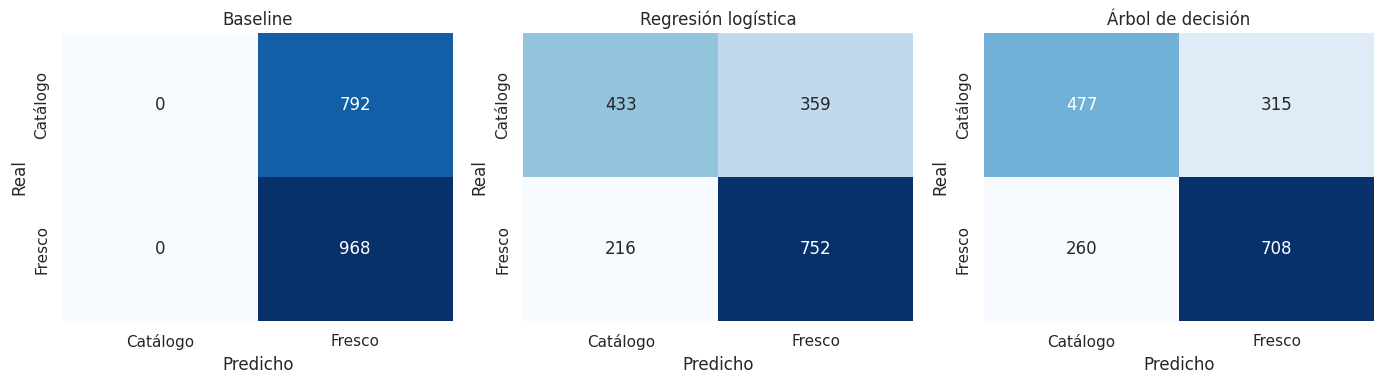

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
modelos = {"Baseline": baseline, "Regresión logística": modelo_log, "Árbol de decisión": modelo_tree}

for ax, (nombre, modelo) in zip(axes, modelos.items()):
    cm = confusion_matrix(y_test, modelo.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Catálogo", "Fresco"], yticklabels=["Catálogo", "Fresco"])
    ax.set_title(nombre)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()


## 8. ¿Qué variables pesan más?

Para el árbol, la importancia de cada variable (cuánto reduce la impureza); para la
regresión logística, el tamaño de su coeficiente (positivo = sube la probabilidad de
"fresco", negativo = la baja).


In [ ]:
importancia_arbol = pd.Series(modelo_tree.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 10 variables más importantes (árbol de decisión):")
print(importancia_arbol.head(10).round(3))


Top 10 variables más importantes (árbol de decisión):
rating_TV-MA                       0.256
genero_documentaries               0.083
genero_international_movies        0.066
type_Movie                         0.064
genero_children_y_family_movies    0.036
rating_TV-14                       0.030
genero_action_y_adventure          0.028
pais_principal_agrupado_India      0.026
pais_principal_agrupado_Spain      0.025
genero_comedies                    0.025
dtype: float64


In [ ]:
coeficientes_log = pd.Series(modelo_log.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print("Top 10 coeficientes más fuertes (regresión logística):")
print(coeficientes_log.head(10).round(3))


Top 10 coeficientes más fuertes (regresión logística):
rating_TV-MA                     1.502
pais_principal_agrupado_Spain    1.358
rating_G                        -1.147
rating_PG                       -0.891
pais_principal_agrupado_Japan   -0.866
rating_PG-13                    -0.859
rating_R                        -0.661
rating_TV-14                     0.642
genero_documentaries             0.610
rating_TV-PG                     0.589
dtype: float64


**Lectura:** en ambos modelos, `rating_TV-MA` es la variable más influyente — el
contenido clasificado para audiencia madura tiende a entrar más fresco. Le siguen el
género documental, el tipo de contenido y el país (España sube la probabilidad de
"fresco"; Japón la baja, coherente con un catálogo de anime más antiguo y licenciado).
Esto confirma que género, tipo, clasificación y país sí contienen señal real sobre la
frescura del catálogo — a diferencia de `type`, que no tenía relación con ninguna
pregunta de negocio.
